In [1]:
from __future__ import annotations

import heapq
import math
import sys
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import h5py
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from scipy import ndimage as ndi
from tqdm.auto import tqdm

ROOT = Path.cwd().resolve()
if ROOT.name == 'research':
    ROOT = ROOT.parent

RESEARCH_ROOT = ROOT / 'research'
MT_ROOT = ROOT / 'mt-py-tools'
sys.path.insert(0, str(MT_ROOT / 'src'))

from mtlib.dataset import connected_components_8, haversine_m
from mtlib.nn import (
    GridConfig,
    ResUNetAttention,
    TrackInpaintDataset,
    load_checkpoint,
    load_density_npz,
    load_frags,
    load_track_index,
    read_track_fragment,
)

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'viridis'
plt.rcParams['axes.grid'] = False

/opt/homebrew/anaconda3/envs/research/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
rng = np.random.default_rng(SEED)

DATASET_PATH = MT_ROOT / 'mt_sorted.h5'
ARTIFACT_DIR = MT_ROOT / 'runs' / 'artifacts'
CHECKPOINT_PATH = MT_ROOT / 'runs' / 'mt-v2' / 'checkpoints' / 'best.pt'

for path in [DATASET_PATH, ARTIFACT_DIR, CHECKPOINT_PATH]:
    assert path.exists(), f'Missing path: {path}'

print(f'ROOT           : {ROOT}')
print(f'DATASET_PATH   : {DATASET_PATH}')
print(f'ARTIFACT_DIR   : {ARTIFACT_DIR}')
print(f'CHECKPOINT_PATH: {CHECKPOINT_PATH}')

ROOT           : /Volumes/SSD/mark/Documents/Projects/marinetraffic-collector
DATASET_PATH   : /Volumes/SSD/mark/Documents/Projects/marinetraffic-collector/mt-py-tools/mt_sorted.h5
ARTIFACT_DIR   : /Volumes/SSD/mark/Documents/Projects/marinetraffic-collector/mt-py-tools/runs/artifacts
CHECKPOINT_PATH: /Volumes/SSD/mark/Documents/Projects/marinetraffic-collector/mt-py-tools/runs/mt-v2/checkpoints/best.pt


In [3]:
grid_cfg = GridConfig()

frags_train = load_frags(ARTIFACT_DIR / 'frags_train.parquet')
frags_val = load_frags(ARTIFACT_DIR / 'frags_val.parquet')
track_index = load_track_index(ARTIFACT_DIR / 'track_index.pkl')
density_map, density_geo, global_extent = load_density_npz(ARTIFACT_DIR / 'density.npz')

DEMO_INDEX = 0

demo_ds = TrackInpaintDataset(
    dataset_path=DATASET_PATH,
    frags_path=ARTIFACT_DIR / 'frags_val.parquet',
    track_index_path=ARTIFACT_DIR / 'track_index.pkl',
    density_path=ARTIFACT_DIR / 'density.npz',
    grid_cfg=grid_cfg,
    seed=123,
    return_meta=True,
)

example = demo_ds[DEMO_INDEX]
meta = example['meta']

h5 = h5py.File(DATASET_PATH, 'r')
fragment = read_track_fragment(
    h5,
    track_index,
    meta['track_id'],
    meta['s'],
    meta['e'],
)

print('train fragments:', len(frags_train))
print('val fragments  :', len(frags_val))
print('track index    :', len(track_index))
print('density shape  :', density_map.shape, density_map.dtype)
print('demo meta      :', meta)
display(frags_val.head())

train fragments: 426
val fragments  : 10
track index    : 1391
density shape  : (4787, 5750) uint32
demo meta      : {'idx': 0, 'track_id': 30471, 's': 5, 'e': 70, 'points': 65, 't0': 1730215470, 't1': 1730256452, 'extent': [127.86747622012064, 128.87231564999655, 34.41849717504138, 35.243310838874635], 'gaps': [(5, 60)]}


,track_id,s,e,points,t0,t1,min_lat,min_lon,max_lat,max_lon
0,30471,5,70,65,1730215470,1730256452,34.465179,127.902496,35.196629,128.837296
1,41909,0,32,32,1730241212,1730261636,34.740311,128.687698,35.483990,129.425797
2,54662,0,54,54,1730272194,1730305484,34.552189,138.091293,35.539490,139.898895
3,54662,54,94,40,1730306772,1730330697,34.524239,136.671204,34.992989,137.980499
4,65499,1,52,51,1730294978,1730328116,33.654861,130.234207,34.038330,131.011200


gap indices   : (5, 60)
gap length    : 55 points
gap jump dist : 89,052.7 m


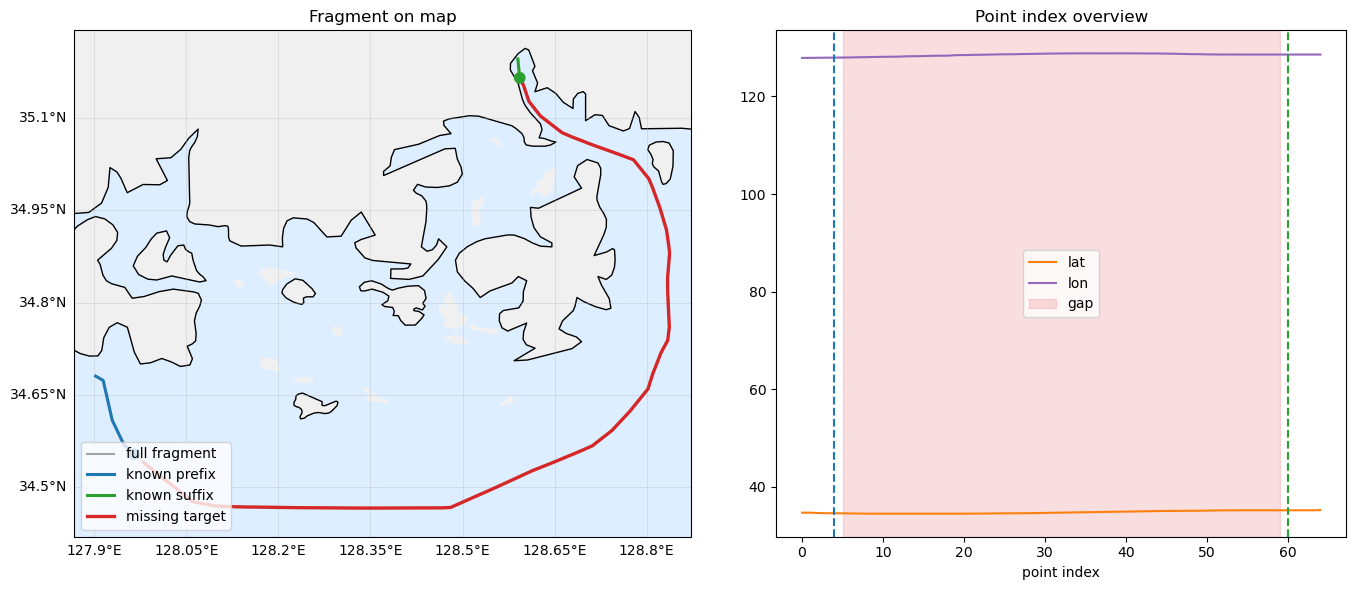

In [4]:
def set_map_style(ax):
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
    ax.add_feature(cfeature.OCEAN, facecolor='#dceeff')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, alpha=0.35, linewidth=0.6)
    gl.top_labels = False
    gl.right_labels = False


def point_to_grid_cell(lat, lon, extent, cfg):
    min_lon, max_lon, min_lat, max_lat = map(float, extent)
    w = h = int(cfg.grid_size)
    x = int(np.clip(np.floor((float(lon) - min_lon) / max(1e-12, max_lon - min_lon) * w), 0, w - 1))
    y = int(np.clip(np.floor((float(lat) - min_lat) / max(1e-12, max_lat - min_lat) * h), 0, h - 1))
    return y, x


def cells_to_lonlat(cells, extent, cfg):
    if not cells:
        return np.empty((0, 2), dtype=np.float64)

    min_lon, max_lon, min_lat, max_lat = map(float, extent)
    h = w = int(cfg.grid_size)

    rows = []
    for y, x in cells:
        lon = min_lon + ((x + 0.5) / w) * (max_lon - min_lon)
        lat = min_lat + ((y + 0.5) / h) * (max_lat - min_lat)
        rows.append((lat, lon))

    return np.asarray(rows, dtype=np.float64)


def make_anchor_mask(shape, cell, radius=2):
    mask = np.zeros(shape, dtype=bool)
    cy, cx = map(int, cell)
    yy, xx = np.ogrid[:shape[0], :shape[1]]
    mask[(yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2] = True
    return mask


def component_label_image(mask):
    labels = np.zeros(mask.shape, dtype=np.int32)
    clusters = connected_components_8(mask.astype(bool), min_cells=1)
    for idx, cells in enumerate(clusters, start=1):
        ys = cells[:, 0]
        xs = cells[:, 1]
        labels[ys, xs] = idx
    return labels, clusters


def plot_fragment_and_gap(fragment, gap, extent):
    fig = plt.figure(figsize=(14, 6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1.0])

    ax_map = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
    set_map_style(ax_map)

    lat = fragment['lat'].astype(np.float64)
    lon = fragment['lon'].astype(np.float64)
    g0, g1 = gap

    ax_map.set_extent(extent, crs=ccrs.PlateCarree())
    ax_map.plot(lon, lat, color='0.65', linewidth=1.5, transform=ccrs.PlateCarree(), label='full fragment')
    ax_map.plot(lon[:g0], lat[:g0], color='tab:blue', linewidth=2.2, transform=ccrs.PlateCarree(), label='known prefix')
    ax_map.plot(lon[g1:], lat[g1:], color='tab:green', linewidth=2.2, transform=ccrs.PlateCarree(), label='known suffix')
    ax_map.plot(lon[g0:g1], lat[g0:g1], color='tab:red', linewidth=2.4, transform=ccrs.PlateCarree(), label='missing target')
    ax_map.scatter([lon[g0 - 1], lon[g1]], [lat[g0 - 1], lat[g1]], s=55, c=['tab:blue', 'tab:green'], transform=ccrs.PlateCarree(), zorder=5)
    ax_map.set_title('Fragment on map')
    ax_map.legend(loc='lower left')

    ax_plot = fig.add_subplot(gs[0, 1])
    step = np.arange(len(fragment))
    ax_plot.plot(step, lat, label='lat', color='tab:orange')
    ax_plot.plot(step, lon, label='lon', color='tab:purple')
    ax_plot.axvspan(g0, g1 - 1, color='tab:red', alpha=0.15, label='gap')
    ax_plot.axvline(g0 - 1, color='tab:blue', linestyle='--')
    ax_plot.axvline(g1, color='tab:green', linestyle='--')
    ax_plot.set_title('Point index overview')
    ax_plot.set_xlabel('point index')
    ax_plot.legend()

    fig.tight_layout()
    return fig


gap = tuple(meta['gaps'][0])
window_extent = tuple(meta['extent'])
plot_fragment_and_gap(fragment, gap, window_extent)

gap_len = gap[1] - gap[0]
gap_dist_m = float(haversine_m(fragment['lat'][gap[0] - 1], fragment['lon'][gap[0] - 1], fragment['lat'][gap[1]], fragment['lon'][gap[1]]))
print(f'gap indices   : {gap}')
print(f'gap length    : {gap_len} points')
print(f'gap jump dist : {gap_dist_m:,.1f} m')

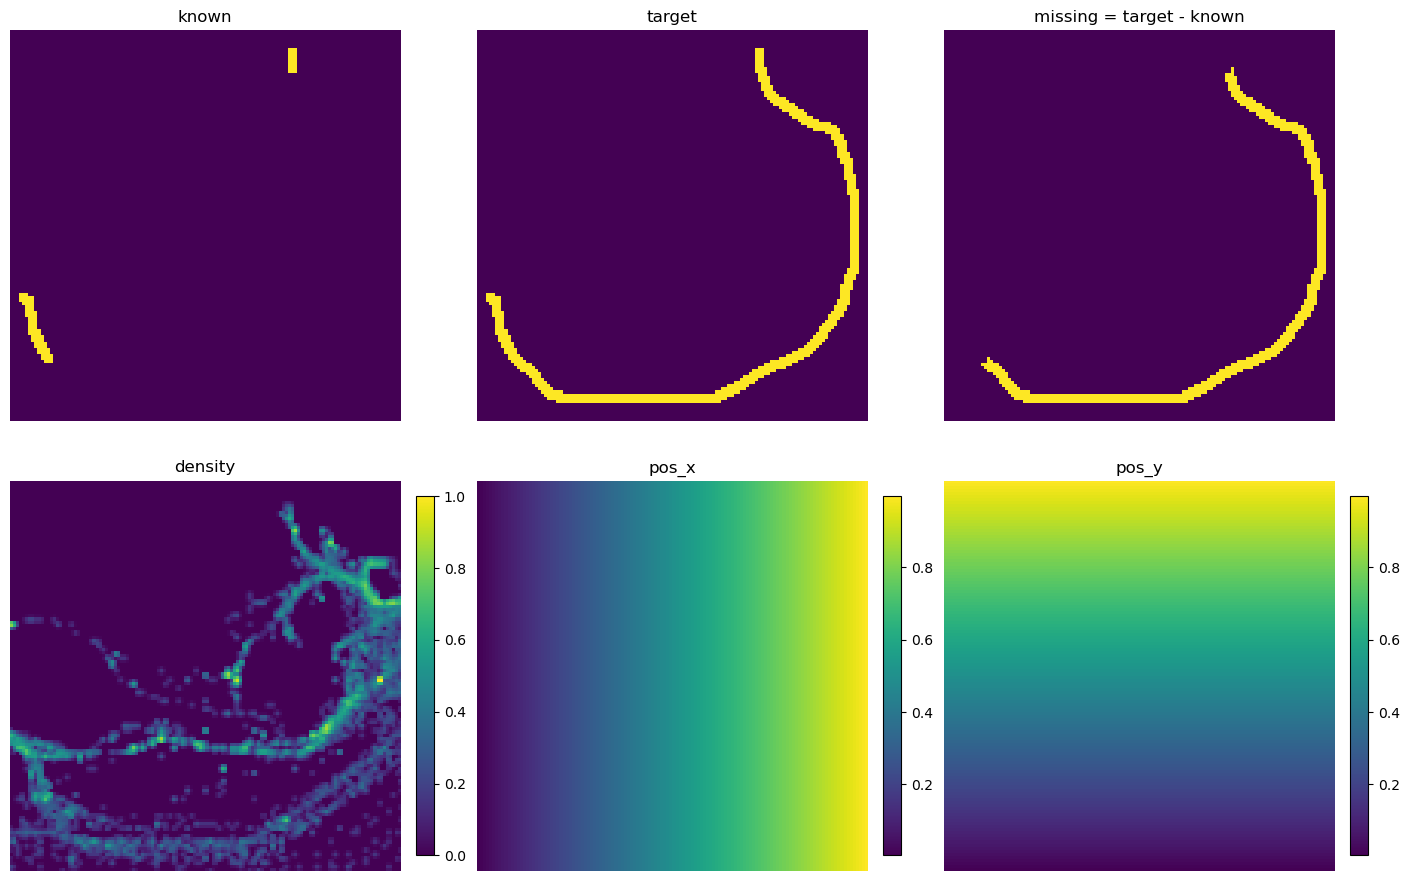

x shape: (4, 128, 128)
y shape: (128, 128)
known pixels  : 110
target pixels : 825
missing pixels: 715


In [5]:
x = example['x'].numpy()
y = example['y'].numpy()[0]
known = x[0]
pos_x = x[1]
pos_y = x[2]
density = x[3]
missing = np.clip(y - known, 0.0, 1.0)

fig, axs = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)

im0 = axs[0, 0].imshow(known, origin='lower', vmin=0.0, vmax=1.0)
axs[0, 0].set_title('known')
axs[0, 0].axis('off')

im1 = axs[0, 1].imshow(y, origin='lower', vmin=0.0, vmax=1.0)
axs[0, 1].set_title('target')
axs[0, 1].axis('off')

im2 = axs[0, 2].imshow(missing, origin='lower', vmin=0.0, vmax=1.0)
axs[0, 2].set_title('missing = target - known')
axs[0, 2].axis('off')

im3 = axs[1, 0].imshow(density, origin='lower')
axs[1, 0].set_title('density')
axs[1, 0].axis('off')
fig.colorbar(im3, ax=axs[1, 0], fraction=0.046, pad=0.04)

im4 = axs[1, 1].imshow(pos_x, origin='lower')
axs[1, 1].set_title('pos_x')
axs[1, 1].axis('off')
fig.colorbar(im4, ax=axs[1, 1], fraction=0.046, pad=0.04)

im5 = axs[1, 2].imshow(pos_y, origin='lower')
axs[1, 2].set_title('pos_y')
axs[1, 2].axis('off')
fig.colorbar(im5, ax=axs[1, 2], fraction=0.046, pad=0.04)

plt.show()

print('x shape:', x.shape)
print('y shape:', y.shape)
print('known pixels  :', int((known > 0).sum()))
print('target pixels :', int((y > 0).sum()))
print('missing pixels:', int((missing > 0).sum()))

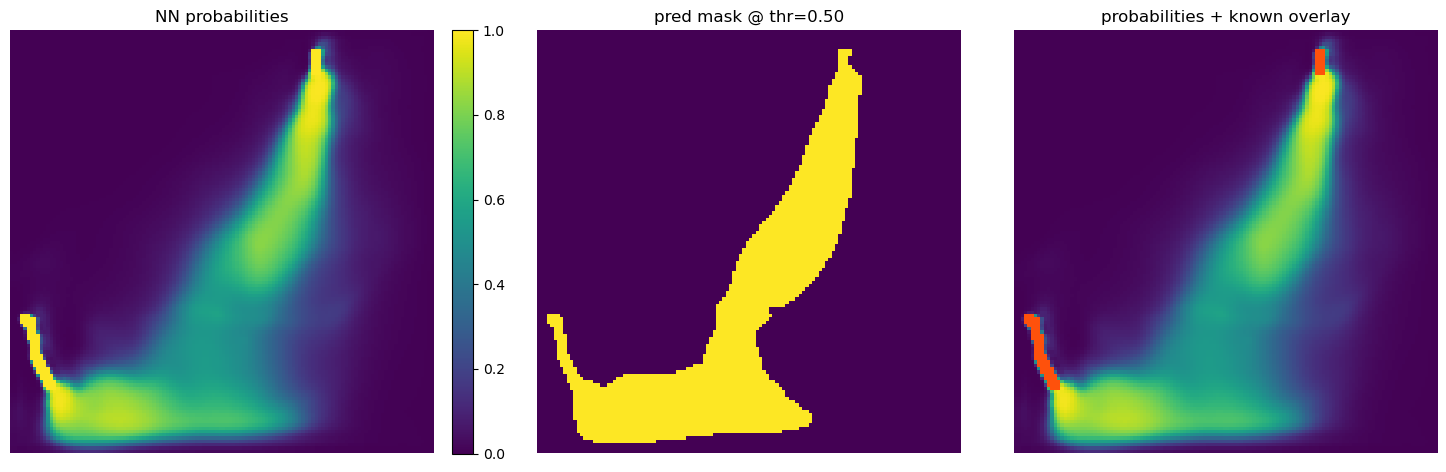

device        : mps
prob min/max  : 1.9771612642216496e-05 0.9999995231628418
prob mean     : 0.19179141521453857
pred pixels   : 3007


In [6]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = ResUNetAttention(in_ch=4, out_ch=1, base_ch=32, groups=8, attn_heads=4).to(device)
load_checkpoint(CHECKPOINT_PATH, model=model, map_location=device)
model.eval()

with torch.no_grad():
    logits = model(example['x'].unsqueeze(0).to(device))
    probs = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()

pred_thr = float(grid_cfg.pred_thr)
pred_mask = probs >= pred_thr

fig, axs = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)

im0 = axs[0].imshow(probs, origin='lower', vmin=0.0, vmax=1.0)
axs[0].set_title('NN probabilities')
axs[0].axis('off')
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

axs[1].imshow(pred_mask.astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)
axs[1].set_title(f'pred mask @ thr={pred_thr:.2f}')
axs[1].axis('off')

axs[2].imshow(probs, origin='lower', vmin=0.0, vmax=1.0)
axs[2].imshow(np.ma.masked_where(known <= 0, known), origin='lower', cmap='autumn', alpha=0.65)
axs[2].set_title('probabilities + known overlay')
axs[2].axis('off')

plt.show()

print('device        :', device)
print('prob min/max  :', float(probs.min()), float(probs.max()))
print('prob mean     :', float(probs.mean()))
print('pred pixels   :', int(pred_mask.sum()))

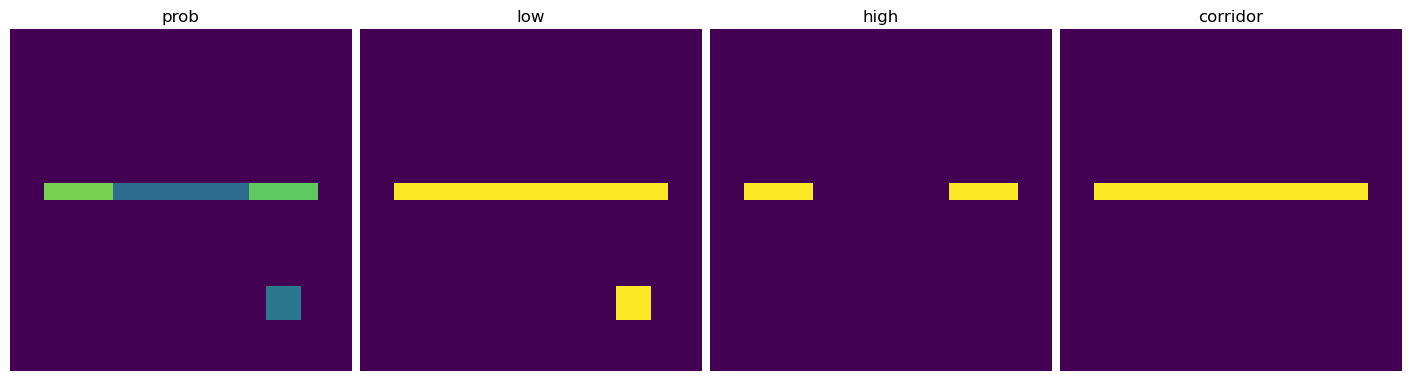

low pixels     : 20
high pixels    : 8
corridor pixels: 16
noise island in corridor: False


In [25]:
NEIGHBORS8 = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1),           (0, 1),
    (1, -1),  (1, 0),  (1, 1),
]


def build_hysteresis_corridor(prob_map, start_mask, end_mask, low_thr=0.20, high_thr=0.55):
    """
    Построение "коридора кандидатов" из вероятностной карты.

    Идея функции:
    1. У нас есть карта вероятностей prob_map размера H x W.
       В каждой клетке лежит вероятность того, что маршрут проходит через эту клетку.
    2. Один жесткий порог обычно работает плохо:
       - высокий порог дает разрывы
       - низкий порог дает слишком много мусора
    3. Поэтому используются два порога:
       - low_thr  : широкий допустимый коридор
       - high_thr : уверенное ядро маршрута
    4. Затем берем только те low-клетки, которые достижимы из high-клеток
       или anchor-масок старта/финиша.

    Вход:
    - prob_map   : np.ndarray shape=(H, W), значения обычно в [0, 1]
    - start_mask : bool-маска стартовой области
    - end_mask   : bool-маска конечной области
    - low_thr    : нижний порог для широкого коридора
    - high_thr   : верхний порог для уверенного ядра

    Выход:
    dict с полями:
    - 'low'      : все клетки, где prob_map >= low_thr
    - 'high'     : все клетки, где prob_map >= high_thr
    - 'corridor' : только та часть low, которая связана с ядром/anchors

    Почему это полезно:
    - isolated noise islands обычно не связаны с ядром и отбрасываются
    - слабые, но нужные участки маршрута сохраняются, если они примыкают к сильной части
    """

    # Широкий допустимый набор клеток
    # Маршрут МОЖЕТ идти по этим клеткам
    low = prob_map >= float(low_thr)

    # Уверенное ядро
    # Сеть особенно уверена, что маршрут точно проходит тут
    high = prob_map >= float(high_thr)

    # allowed = где вообще можно расти при обходе
    # Это low-область плюс стартовая и конечная anchor-зоны
    # Даже если anchor-клетки ниже low_thr, мы все равно явно разрешаем их использовать
    allowed = low | start_mask | end_mask

    # seeds = начальные клетки, от которых стартует flood-fill / DFS (поиск в глубину)
    # Растем от уверенного ядра и от anchor-точек
    seeds = high | start_mask | end_mask

    # Итоговый коридор
    # Изначально пустой
    corridor = np.zeros_like(allowed, dtype=bool)

    # Начальный стек для обхода в глубину - DFS
    # Берем все клетки, которые одновременно являются и seed, и допустимы для роста
    stack = [tuple(pt) for pt in np.argwhere(seeds & allowed)]

    while stack:
        y, x = stack.pop()

        # Если клетка уже посещалась, пропускаем
        if corridor[y, x]:
            continue

        # Включаем клетку в итоговый коридор
        corridor[y, x] = True

        # Смотрим всех 8 соседей
        for dy, dx in NEIGHBORS8:
            ny = y + dy
            nx = x + dx

            # Расширяемся только внутри массива
            # только по разрешенным клеткам,
            # и только туда, где ещё не были
            if (
                0 <= ny < corridor.shape[0]
                and 0 <= nx < corridor.shape[1]
                and allowed[ny, nx]
                and not corridor[ny, nx]
            ):
                stack.append((ny, nx))

    return {
        'low': low,
        'high': high,
        'corridor': corridor,
    }


prob = np.zeros((20, 20), dtype=np.float32)

# Основной маршрут с уверенным ядром и более слабым хвостом
prob[10, 2:6] = 0.80
prob[10, 6:14] = 0.35
prob[10, 14:18] = 0.75

# Шумовой остров, который не связан с маршрутом
prob[3:5, 15:17] = 0.40

start_mask = np.zeros_like(prob, dtype=bool)
end_mask = np.zeros_like(prob, dtype=bool)
start_mask[10, 2] = True
end_mask[10, 17] = True

res = build_hysteresis_corridor(
    prob,
    start_mask,
    end_mask,
    low_thr=0.20,
    high_thr=0.60,
)

fig, axs = plt.subplots(1, 4, figsize=(14, 3.8), constrained_layout=True)

axs[0].imshow(prob, origin='lower', vmin=0.0, vmax=1.0)
axs[0].set_title('prob')
axs[0].axis('off')

axs[1].imshow(res['low'].astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)
axs[1].set_title('low')
axs[1].axis('off')

axs[2].imshow(res['high'].astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)
axs[2].set_title('high')
axs[2].axis('off')

axs[3].imshow(res['corridor'].astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)
axs[3].set_title('corridor')
axs[3].axis('off')

plt.show()

print('low pixels     :', int(res['low'].sum()))
print('high pixels    :', int(res['high'].sum()))
print('corridor pixels:', int(res['corridor'].sum()))
print('noise island in corridor:', bool(res['corridor'][3:5, 15:17].any()))

Ожидаемое поведение:
- основная горизонтальная линия должна целиком попасть в `corridor`
- шумный островок справа снизу должен остаться вне `corridor`

In [27]:
def _neighbors_clockwise(img, y, x):
    """
    Возвращает 8 соседей клетки (y, x) по часовой стрелке

    Порядок:
    p0 = север        = (y-1, x)
    p1 = северо-восток= (y-1, x+1)
    p2 = восток       = (y,   x+1)
    p3 = юго-восток   = (y+1, x+1)
    p4 = юг           = (y+1, x)
    p5 = юго-запад    = (y+1, x-1)
    p6 = запад        = (y,   x-1)
    p7 = северо-запад = (y-1, x-1)

    Этот порядок нужен для алгоритма Zhang-Suen thinning
    Там важно считать:
    - B(p): сколько соседей вообще включено
    - A(p): сколько раз при обходе по кругу происходит переход 0 -> 1

    Именно поэтому нужен не просто набор соседей, а фиксированный циклический порядок.
    """
    return [
        img[y - 1, x],
        img[y - 1, x + 1],
        img[y, x + 1],
        img[y + 1, x + 1],
        img[y + 1, x],
        img[y + 1, x - 1],
        img[y, x - 1],
        img[y - 1, x - 1],
    ]

img = np.arange(25, dtype=np.int32).reshape(5, 5)
center_y, center_x = 2, 2

print(img)
print('_neighbors_clockwise(img, 2, 2) =')
print(_neighbors_clockwise(img, center_y, center_x))

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]
_neighbors_clockwise(img, 2, 2) =
[7, 8, 13, 18, 17, 16, 11, 6]


Ожидаемый порядок вокруг (2, 2):
- север
- северо-восток
- восток
- юго-восток
- юг
- юго-запад
- запад
- северо-запад

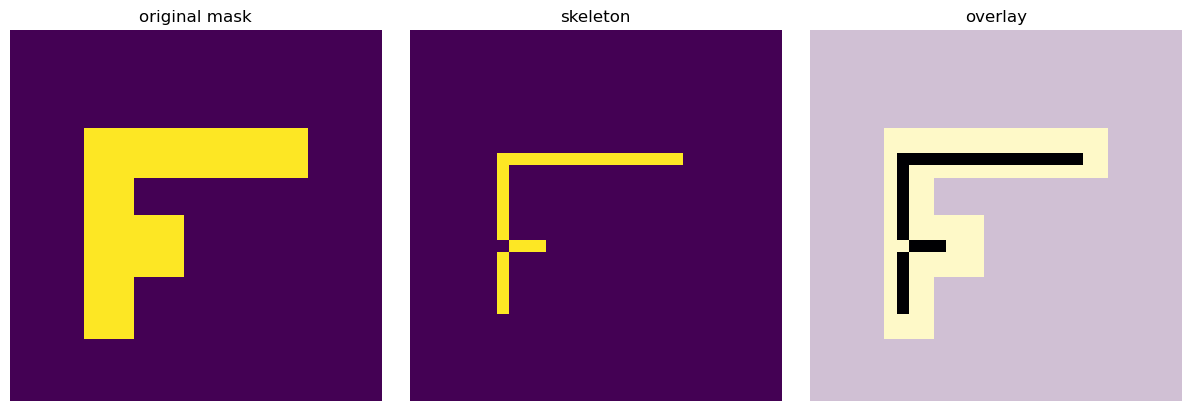

original pixels: 144
skeleton pixels: 29


In [29]:
def zhang_suen_thinning(mask, max_iters=64, verbose=False):
    """
    Скелетизация бинарной маски алгоритмом Zhang-Suen

    Цель:
    - на входе толстая бинарная линия/область
    - на выходе ее скелет толщиной примерно в 1 пиксель

    Зачем?:
    - сеть обычно предсказывает не тонкую линию, а толстую полосу вероятностей (для улучшения точности изначально данные в выборке такие)
    - по толстой полосе неудобно строить граф маршрута
    - скелетизация сжимает полосу до центральной оси

    Как работает Zhang-Suen:
    - алгоритм итеративно удаляет граничные пиксели
    - удаляет их очень аккуратно, чтобы не разрушить топологию объекта
    - за одну итерацию делает два подшага удаления
    - останавливается, когда больше ничего удалить нельзя

    Пояснение ключевых величин:
    - B(p) = число ненулевых соседей у пикселя p
      Если соседей слишком мало или слишком много, пиксель не удаляем
    - A(p) = число переходов 0->1 при обходе соседей по кругу
      Если A(p) == 1, это означает, что вокруг пикселя одна связная ветка
      Если больше, удаление могло бы разорвать связность

    Вход:
    - mask      : бинарная маска shape=(H, W)
    - max_iters : максимальное число итераций, чтобы не зациклиться
    - verbose   : показывать tqdm-прогресс

    Выход:
    - bool-маска того же размера, содержащая skeleton
    """

    # Паддинг нужен, чтобы безопасно читать соседей по краям
    # После завершения мы его срежем.
    img = np.pad(mask.astype(np.uint8), 1, mode='constant')

    iterator = range(max_iters)
    if verbose:
        iterator = tqdm(iterator, desc='zhang-suen', leave=False)

    for _ in iterator:
        changed = False

        # Подшаг 1
        to_remove = []
        ys, xs = np.nonzero(img)

        for y, x in zip(ys, xs, strict=False):
            # Край padding не трогаем, там нет полного окружения
            if y == 0 or x == 0 or y == img.shape[0] - 1 or x == img.shape[1] - 1:
                continue

            p = _neighbors_clockwise(img, y, x)

            # B(p): сколько соседей включено
            b = sum(p)

            # A(p): число переходов 0 -> 1 при обходе по кругу
            a = sum((p[i] == 0 and p[(i + 1) % 8] == 1) for i in range(8))

            # Условия Zhang-Suen для подшага 1
            # 2 <= b <= 6   -> пиксель не изолирован и не слишком внутренний
            # a == 1        -> удаление не разрывает объект на несколько частей
            # дополнительные произведения предотвращают разрушение связности
            if 2 <= b <= 6 and a == 1 and p[0] * p[2] * p[4] == 0 and p[2] * p[4] * p[6] == 0:
                to_remove.append((y, x))

        if to_remove:
            changed = True
            for y, x in to_remove:
                img[y, x] = 0

        # Подшаг 2
        to_remove = []
        ys, xs = np.nonzero(img)

        for y, x in zip(ys, xs, strict=False):
            if y == 0 or x == 0 or y == img.shape[0] - 1 or x == img.shape[1] - 1:
                continue

            p = _neighbors_clockwise(img, y, x)
            b = sum(p)
            a = sum((p[i] == 0 and p[(i + 1) % 8] == 1) for i in range(8))

            # Условия второго подшага немного отличаются
            # Это сделано специально, чтобы thinning происходил симметрично
            # и объект не схлопывался со сдвигом в одну сторону
            if 2 <= b <= 6 and a == 1 and p[0] * p[2] * p[6] == 0 and p[0] * p[4] * p[6] == 0:
                to_remove.append((y, x))

        if to_remove:
            changed = True
            for y, x in to_remove:
                img[y, x] = 0

        # Если за полную итерацию не удалилось ни одного пикселя,
        # значит алгоритм стабилизировался
        if not changed:
            break

    # Убираем padding и возвращаем bool-маску
    return img[1:-1, 1:-1].astype(bool)

mask = np.zeros((30, 30), dtype=bool)

# Толстая "Г"-образная линия
mask[5:22, 6:10] = True
mask[18:22, 6:24] = True

# Небольшое утолщение
mask[10:15, 9:14] = True

skeleton = zhang_suen_thinning(mask, verbose=True)

fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

axs[0].imshow(mask.astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)
axs[0].set_title('original mask')
axs[0].axis('off')

axs[1].imshow(skeleton.astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)
axs[1].set_title('skeleton')
axs[1].axis('off')

axs[2].imshow(mask.astype(np.float32), origin='lower', alpha=0.25)
axs[2].imshow(np.ma.masked_where(~skeleton, skeleton), origin='lower', cmap='magma')
axs[2].set_title('overlay')
axs[2].axis('off')

plt.show()

print('original pixels:', int(mask.sum()))
print('skeleton pixels:', int(skeleton.sum()))

Ожидаемое поведение:
- `skeleton` заметно меньше
- центральная ось формы должна сохраниться

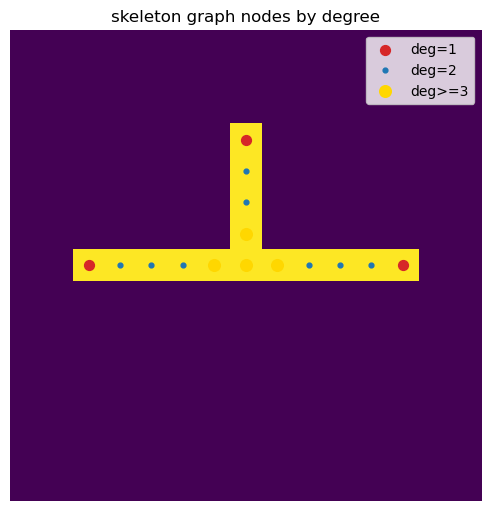

nodes: 15
edges: 16
deg=1: 3 [(7, 2), (7, 12), (11, 7)]
deg=2: 8
deg>=3: 4 [(7, 6), (7, 7), (7, 8), (8, 7)]


In [30]:
def build_skeleton_graph(skeleton, prob_map):
    """
    Превращает skeleton-маску в граф NetworkX

    Идея:
    - каждая включенная клетка skeleton становится вершиной графа
    - если две клетки являются 8-соседями, между ними создается ребро

    Зачем?:
    - после скелетизации мы имеем тонкую линию маршрута
    - граф позволяет искать путь от старта к финишу алгоритмами на графах
    - по степеням вершин можно находить концы, развилки, тупики

    Что кладется в вершины:
    - prob : вероятность в данной клетке

    Что кладётся в ребра:
    - dist   : геометрическая длина шага (1.0 или sqrt(2))
    - weight : стоимость перехода

    Как считается weight:
    - берем среднюю вероятность на двух концах ребра
    - переводим её в стоимость через -log(p)
    - умножаем на длину шага

    Почему -log(p):
    - высокая вероятность -> маленькая цена
    - низкая вероятность  -> большая цена
    - суммы таких весов естественно подходят для shortest path
    """
    graph = nx.Graph()

    # Все активные клетки skeleton
    coords = [tuple(map(int, pt)) for pt in np.argwhere(skeleton)]
    coord_set = set(coords)

    # Добавляем вершины графа
    for node in coords:
        y, x = node
        graph.add_node(node, prob=float(prob_map[y, x]))

    # Добавляем ребра между соседними клетками skeleton
    for y, x in coords:
        for dy, dx in NEIGHBORS8:
            nbr = (y + dy, x + dx)

            # Если соседа нет в skeleton или ребро уже создано, пропускаем
            if nbr not in coord_set or graph.has_edge((y, x), nbr):
                continue

            # Диагональ длиннее обычного шага
            dist = math.sqrt(2.0) if dy != 0 and dx != 0 else 1.0

            # Вероятность на ребре берем как среднюю по двум концам
            p = max(1e-6, 0.5 * (float(prob_map[y, x]) + float(prob_map[nbr[0], nbr[1]])))

            graph.add_edge(
                (y, x),
                nbr,
                weight=(-math.log(p)) * dist,
                dist=dist,
            )

    return graph

skeleton = np.zeros((15, 15), dtype=bool)

# Т-образный skeleton
skeleton[7, 2:13] = True
skeleton[7:12, 7] = True

prob = np.zeros_like(skeleton, dtype=np.float32) + 0.1
prob[skeleton] = 0.8

G = build_skeleton_graph(skeleton, prob)
degrees = dict(G.degree())

degree1 = [n for n, d in degrees.items() if d == 1]
degree2 = [n for n, d in degrees.items() if d == 2]
degree3p = [n for n, d in degrees.items() if d >= 3]

fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
ax.imshow(skeleton.astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)

if degree1:
    ax.scatter([x for y, x in degree1], [y for y, x in degree1], c='tab:red', s=50, label='deg=1')
if degree2:
    ax.scatter([x for y, x in degree2], [y for y, x in degree2], c='tab:blue', s=12, label='deg=2')
if degree3p:
    ax.scatter([x for y, x in degree3p], [y for y, x in degree3p], c='gold', s=70, label='deg>=3')

ax.set_title('skeleton graph nodes by degree')
ax.axis('off')
ax.legend(loc='upper right')
plt.show()

print('nodes:', G.number_of_nodes())
print('edges:', G.number_of_edges())
print('deg=1:', len(degree1), degree1)
print('deg=2:', len(degree2))
print('deg>=3:', len(degree3p), degree3p)

Ожидаемое поведение:
- у концов линии степень 1
- у обычных точек степень 2
- у центра развилки степень 3 или больше

In [31]:
def closest_graph_node(graph, cell):
    """
    Находит ближайшую вершину графа к заданной клетке

    - start/end anchors могут не лежать точно на skeleton
    - поэтому мы должны привязать их к ближайшей вершине графа

    Если граф пустой, вернуть None

    Метрика:
    - обычное квадрат расстояния на решетке
    - без sqrt, потому что для сравнения это не влияет на результат
    """
    if graph.number_of_nodes() == 0:
        return None

    cy, cx = map(float, cell)

    return min(
        graph.nodes,
        key=lambda node: (node[0] - cy) ** 2 + (node[1] - cx) ** 2,
    )

Ожидаемое поведение:
- `(1, 1)` должен притянуться к `(2, 2)`
- `(6, 6)` к `(5, 5)`
- `(7, 2)` к `(8, 1)`

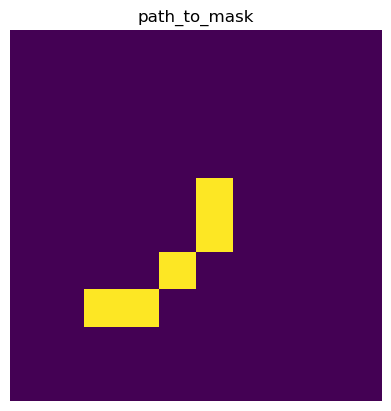

mask nonzero: 5
expected    : 5


In [33]:
def path_to_mask(path, shape):
    """
    Превращает список клеток пути в бинарную/float-маску

    Вход:
    - path  : список клеток [(y, x), ...]
    - shape : размер выходной маски

    Выход:
    - массив shape=(H, W), где клетки пути отмечены единицами

    Зачем это нужно:
    - удобно для визуализации пути поверх probability map
    - удобно для последующего сравнения с target/prediction
    """
    mask = np.zeros(shape, dtype=np.float32)
    for y, x in path:
        mask[int(y), int(x)] = 1.0
    return mask

path = [(2, 2), (2, 3), (3, 4), (4, 5), (5, 5)]
mask = path_to_mask(path, (10, 10))

fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)
ax.imshow(mask, origin='lower', vmin=0.0, vmax=1.0)
ax.set_title('path_to_mask')
ax.axis('off')
plt.show()

print('mask nonzero:', int(mask.sum()))
print('expected    :', len(path))

Ожидаемое поведение:
- число единичных пикселей равно длине path, если в path нет повторов

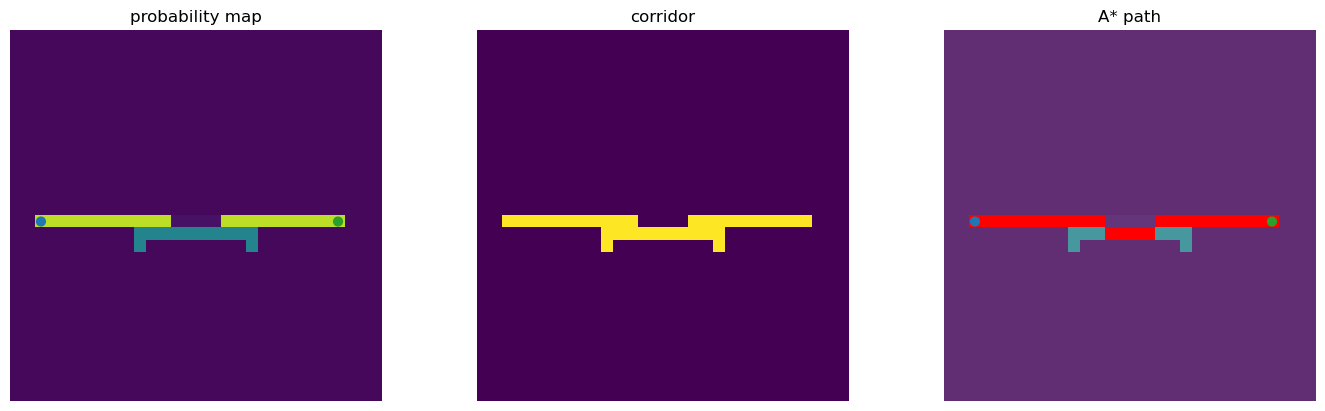

path length: 25
path starts: (14, 2)
path ends  : (14, 26)


In [32]:
def astar_grid_path(prob_map, corridor_mask, start_cell, end_cell, off_corridor_penalty=1.5):
    """
    A* поиск пути прямо на сетке, без skeleton-графа

    Это fallback-алгоритм
    Он нужен на случай, когда:
    - skeleton распался
    - граф не связен
    - start и end не соединяются внутри графа

    Тогда мы ищем путь по всей пиксельной сетке

    Как считается стоимость шага:
    1. Берем вероятность клетки назначения cell_to
    2. Переводим в цену через -log(p)
    3. Если клетка лежит вне corridor_mask, добавляем штраф
    4. Учитываем длину шага (1 или sqrt(2))

    Что это дает:
    - путь предпочитает зоны высокой вероятности
    - путь старается оставаться внутри corridor
    - но если коридор разорван, может выйти за него и достроить мост

    Почему именно A*:
    - это Dijkstra + эвристика до цели
    - на сетке работает быстрее полного Dijkstra

    Выход:
    - список клеток [(y0, x0), (y1, x1), ...]
    - если путь не найден, возвращается []
    """

    h, w = prob_map.shape
    start = tuple(map(int, start_cell))
    goal = tuple(map(int, end_cell))

    def heuristic(cell):
        # Эвристика: евклидово расстояние до цели
        # Это "оптимистичная" оценка оставшегося пути
        return math.hypot(cell[0] - goal[0], cell[1] - goal[1])

    def step_cost(cell_from, cell_to):
        y, x = cell_to

        # Базовая цена по вероятности
        # Чем вероятность ниже, тем стоимость выше
        base = -math.log(max(1e-6, float(prob_map[y, x])))

        # Если выходим за пределы corridor, наказываем дополнительным штрафом
        if not corridor_mask[y, x]:
            base += float(off_corridor_penalty)

        # Учитываем длину шага
        dist = math.sqrt(2.0) if abs(cell_from[0] - y) == 1 and abs(cell_from[1] - x) == 1 else 1.0
        return base * dist

    # Элементы очереди: (f_score, g_score, cell)
    queue = [(heuristic(start), 0.0, start)]

    # came_from нужен для восстановления пути назад от goal к start
    came_from = {}

    # Лучшая известная стоимость достижения клетки
    g_score = {start: 0.0}

    # Чтобы не обрабатывать одну и ту же клетку повторно после финализации
    visited = set()

    while queue:
        _, cur_g, current = heapq.heappop(queue)

        if current in visited:
            continue
        visited.add(current)

        if current == goal:
            break

        cy, cx = current
        for dy, dx in NEIGHBORS8:
            ny = cy + dy
            nx = cx + dx

            if not (0 <= ny < h and 0 <= nx < w):
                continue

            nxt = (ny, nx)
            tentative = cur_g + step_cost(current, nxt)

            if tentative < g_score.get(nxt, float('inf')):
                g_score[nxt] = tentative
                came_from[nxt] = current
                heapq.heappush(queue, (tentative + heuristic(nxt), tentative, nxt))

    # Если goal не был достигнут, пути нет
    if goal not in came_from and goal != start:
        return []

    # Восстановление пути назад
    path = [goal]
    while path[-1] != start:
        path.append(came_from[path[-1]])
    path.reverse()

    return path


prob = np.zeros((30, 30), dtype=np.float32) + 0.02

# Основной вероятный коридор
prob[14, 2:27] = 0.90

# Разрыв в коридоре
prob[14, 13:17] = 0.05

# Обход снизу, но менее уверенный
prob[13, 10:20] = 0.45
prob[12, 10] = 0.45
prob[12, 19] = 0.45
prob[13, 10] = 0.45
prob[13, 19] = 0.45

start = (14, 2)
end = (14, 26)

corridor = prob >= 0.20
path = astar_grid_path(prob, corridor, start, end, off_corridor_penalty=1.5)
path_mask = path_to_mask(path, prob.shape)

fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

axs[0].imshow(prob, origin='lower', vmin=0.0, vmax=1.0)
axs[0].scatter([start[1], end[1]], [start[0], end[0]], c=['tab:blue', 'tab:green'], s=40)
axs[0].set_title('probability map')
axs[0].axis('off')

axs[1].imshow(corridor.astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)
axs[1].set_title('corridor')
axs[1].axis('off')

axs[2].imshow(prob, origin='lower', vmin=0.0, vmax=1.0, alpha=0.85)
axs[2].imshow(np.ma.masked_where(path_mask == 0, path_mask), origin='lower', cmap='autumn')
axs[2].scatter([start[1], end[1]], [start[0], end[0]], c=['tab:blue', 'tab:green'], s=40)
axs[2].set_title('A* path')
axs[2].axis('off')

plt.show()

print('path length:', len(path))
print('path starts:', path[0] if path else None)
print('path ends  :', path[-1] if path else None)

Ожидаемое поведение:
- путь должен соединить старт и конец
- на визуализации видно, как именно алгоритм обходит разрыв

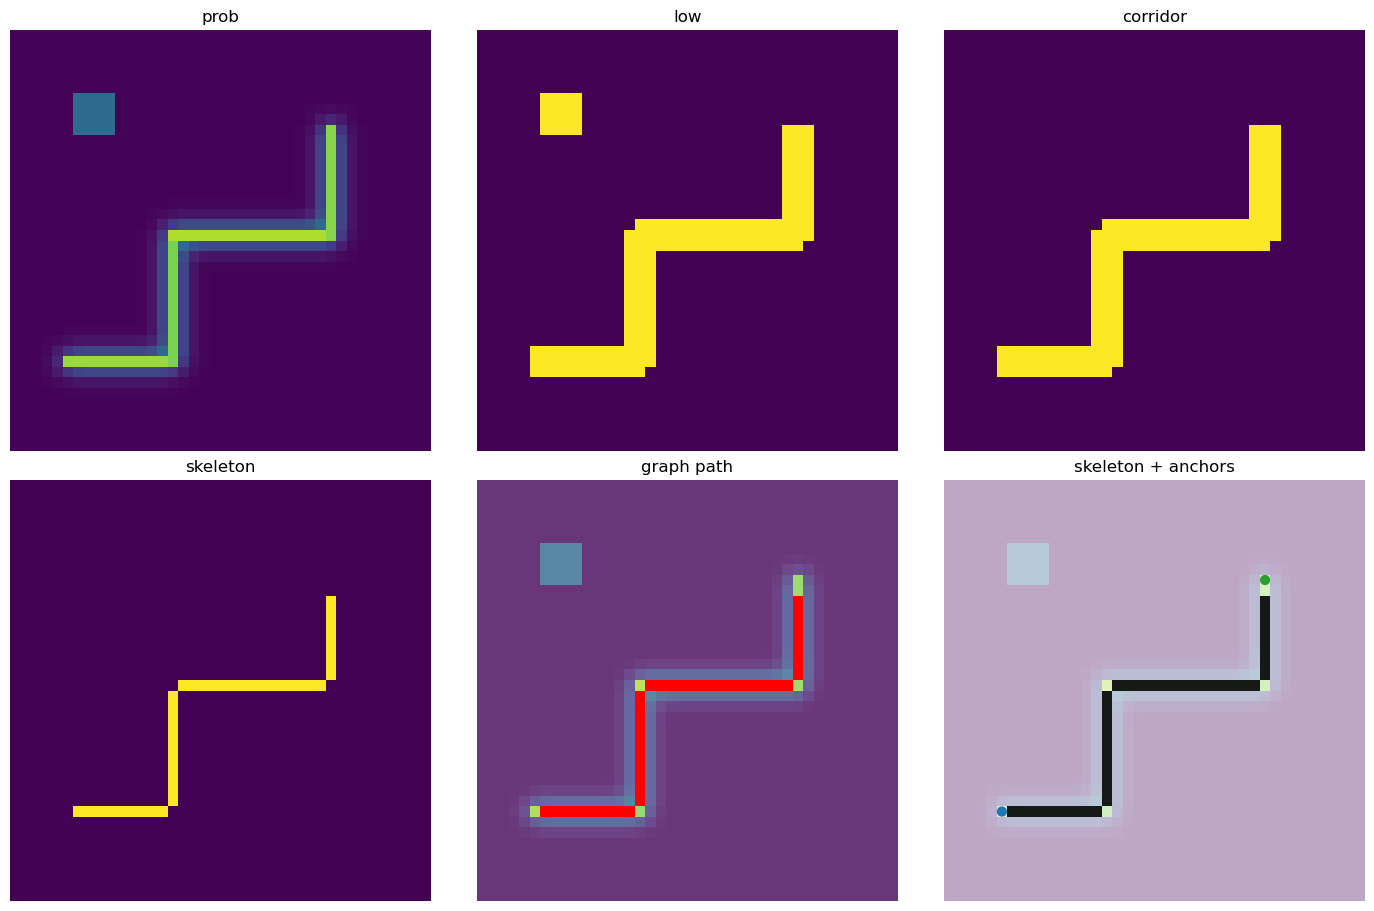

source         : graph path
corridor pixels: 141
skeleton pixels: 42
graph nodes    : 42
graph edges    : 41
path length    : 42


In [24]:
prob = np.zeros((40, 40), dtype=np.float32) + 0.01

# S-образный маршрут
for x in range(5, 16):
    prob[8, x] = 0.85
for y in range(8, 21):
    prob[y, 15] = 0.80
for x in range(15, 31):
    prob[20, x] = 0.88
for y in range(20, 31):
    prob[y, 30] = 0.82

# Чуть расширим коридор вокруг линии
prob = np.maximum(prob, ndi.gaussian_filter(prob, sigma=1.0))

# Добавим шумовой остров
prob[30:34, 6:10] = np.maximum(prob[30:34, 6:10], 0.35)

start_mask = np.zeros_like(prob, dtype=bool)
end_mask = np.zeros_like(prob, dtype=bool)
start_mask[8, 5] = True
end_mask[30, 30] = True

res = build_hysteresis_corridor(prob, start_mask, end_mask, low_thr=0.12, high_thr=0.45)
skeleton = zhang_suen_thinning(res['corridor'], verbose=True)
G = build_skeleton_graph(skeleton, prob)

start_node = closest_graph_node(G, (8, 5))
end_node = closest_graph_node(G, (30, 30))

if start_node is not None and end_node is not None and nx.has_path(G, start_node, end_node):
    path = nx.shortest_path(G, start_node, end_node, weight='weight')
    source = 'graph path'
else:
    path = astar_grid_path(prob, res['corridor'], (8, 5), (30, 30))
    source = 'A* fallback'

path_mask = path_to_mask(path, prob.shape)

fig, axs = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)

axs[0, 0].imshow(prob, origin='lower', vmin=0.0, vmax=1.0)
axs[0, 0].set_title('prob')
axs[0, 0].axis('off')

axs[0, 1].imshow(res['low'].astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)
axs[0, 1].set_title('low')
axs[0, 1].axis('off')

axs[0, 2].imshow(res['corridor'].astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)
axs[0, 2].set_title('corridor')
axs[0, 2].axis('off')

axs[1, 0].imshow(skeleton.astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)
axs[1, 0].set_title('skeleton')
axs[1, 0].axis('off')

axs[1, 1].imshow(prob, origin='lower', vmin=0.0, vmax=1.0, alpha=0.8)
axs[1, 1].imshow(np.ma.masked_where(path_mask == 0, path_mask), origin='lower', cmap='autumn')
axs[1, 1].set_title(source)
axs[1, 1].axis('off')

axs[1, 2].imshow(prob, origin='lower', vmin=0.0, vmax=1.0, alpha=0.35)
axs[1, 2].imshow(np.ma.masked_where(~skeleton, skeleton), origin='lower', cmap='magma', alpha=0.9)
axs[1, 2].scatter([5, 30], [8, 30], c=['tab:blue', 'tab:green'], s=40)
axs[1, 2].set_title('skeleton + anchors')
axs[1, 2].axis('off')

plt.show()

print('source         :', source)
print('corridor pixels:', int(res['corridor'].sum()))
print('skeleton pixels:', int(skeleton.sum()))
print('graph nodes    :', G.number_of_nodes())
print('graph edges    :', G.number_of_edges())
print('path length    :', len(path))

In [20]:
start_cell = point_to_grid_cell(fragment['lat'][gap[0] - 1], fragment['lon'][gap[0] - 1], window_extent, grid_cfg)
end_cell = point_to_grid_cell(fragment['lat'][gap[1]], fragment['lon'][gap[1]], window_extent, grid_cfg)

start_mask = make_anchor_mask(probs.shape, start_cell, radius=2)
end_mask = make_anchor_mask(probs.shape, end_cell, radius=2)

thr_low = 0.20
thr_high = 0.55
hyst = build_hysteresis_corridor(probs, start_mask, end_mask, low_thr=thr_low, high_thr=thr_high)

labels_low, clusters_low = component_label_image(hyst['low'])
labels_corridor, clusters_corridor = component_label_image(hyst['corridor'])

skeleton = zhang_suen_thinning(hyst['corridor'], verbose=True)
skeleton_graph = build_skeleton_graph(skeleton, probs)
start_node = closest_graph_node(skeleton_graph, start_cell)
end_node = closest_graph_node(skeleton_graph, end_cell)

graph_path = []
if start_node is not None and end_node is not None and nx.has_path(skeleton_graph, start_node, end_node):
    graph_path = nx.shortest_path(skeleton_graph, source=start_node, target=end_node, weight='weight')

final_path = graph_path
path_source = 'skeleton graph path'
if not final_path:
    final_path = astar_grid_path(probs, hyst['corridor'], start_cell, end_cell, off_corridor_penalty=1.5)
    path_source = 'full-grid A* fallback'

final_path_geo = cells_to_lonlat(final_path, window_extent, grid_cfg)
missing_true_geo = np.column_stack([fragment['lat'][gap[0]:gap[1]], fragment['lon'][gap[0]:gap[1]]]).astype(np.float64)
final_path_mask = path_to_mask(final_path, probs.shape)

print('start cell           :', start_cell)
print('end cell             :', end_cell)
print('low components       :', len(clusters_low))
print('corridor components  :', len(clusters_corridor))
print('skeleton pixels      :', int(skeleton.sum()))
print('graph nodes / edges  :', skeleton_graph.number_of_nodes(), skeleton_graph.number_of_edges())
print('graph path pixels    :', len(graph_path))
print('final path pixels    :', len(final_path))
print('path source          :', path_source)

Pass2: connected components rows: 100%|██████████| 128/128 [00:00<00:00, 13219.19row/s]
                                                           

start cell           : (20, 12)
end cell             : (115, 92)
low components       : 1
corridor components  : 1
skeleton pixels      : 211
graph nodes / edges  : 211 268
graph path pixels    : 145
final path pixels    : 145
path source          : skeleton graph path


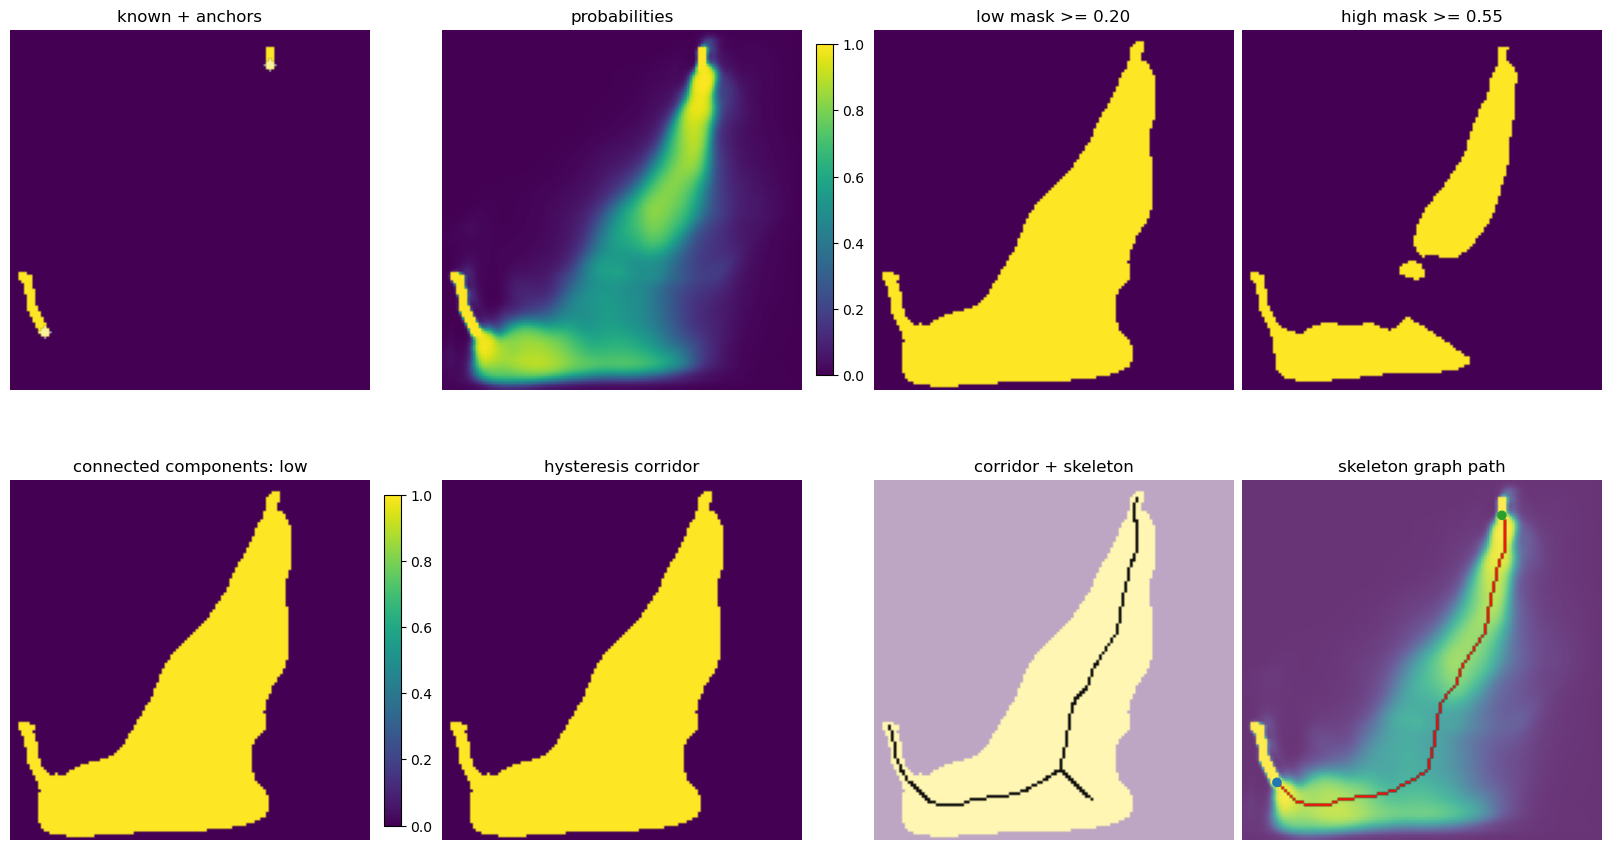

In [21]:
fig, axs = plt.subplots(2, 4, figsize=(16, 9), constrained_layout=True)

axs[0, 0].imshow(known, origin='lower', vmin=0.0, vmax=1.0)
axs[0, 0].imshow(np.ma.masked_where(start_mask == 0, start_mask), origin='lower', cmap='Blues', alpha=0.55)
axs[0, 0].imshow(np.ma.masked_where(end_mask == 0, end_mask), origin='lower', cmap='Greens', alpha=0.55)
axs[0, 0].set_title('known + anchors')
axs[0, 0].axis('off')

im1 = axs[0, 1].imshow(probs, origin='lower', vmin=0.0, vmax=1.0)
axs[0, 1].set_title('probabilities')
axs[0, 1].axis('off')
fig.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.04)

axs[0, 2].imshow(hyst['low'].astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)
axs[0, 2].set_title(f'low mask >= {thr_low:.2f}')
axs[0, 2].axis('off')

axs[0, 3].imshow(hyst['high'].astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)
axs[0, 3].set_title(f'high mask >= {thr_high:.2f}')
axs[0, 3].axis('off')

im4 = axs[1, 0].imshow(labels_low, origin='lower')
axs[1, 0].set_title('connected components: low')
axs[1, 0].axis('off')
fig.colorbar(im4, ax=axs[1, 0], fraction=0.046, pad=0.04)

axs[1, 1].imshow(hyst['corridor'].astype(np.float32), origin='lower', vmin=0.0, vmax=1.0)
axs[1, 1].set_title('hysteresis corridor')
axs[1, 1].axis('off')

axs[1, 2].imshow(hyst['corridor'].astype(np.float32), origin='lower', alpha=0.35)
axs[1, 2].imshow(np.ma.masked_where(~skeleton, skeleton), origin='lower', cmap='magma', alpha=0.95)
axs[1, 2].set_title('corridor + skeleton')
axs[1, 2].axis('off')

axs[1, 3].imshow(probs, origin='lower', vmin=0.0, vmax=1.0, alpha=0.8)
axs[1, 3].imshow(np.ma.masked_where(final_path_mask == 0, final_path_mask), origin='lower', cmap='autumn', alpha=0.95)
axs[1, 3].scatter([start_cell[1], end_cell[1]], [start_cell[0], end_cell[0]], c=['tab:blue', 'tab:green'], s=35)
axs[1, 3].set_title(path_source)
axs[1, 3].axis('off')

plt.show()

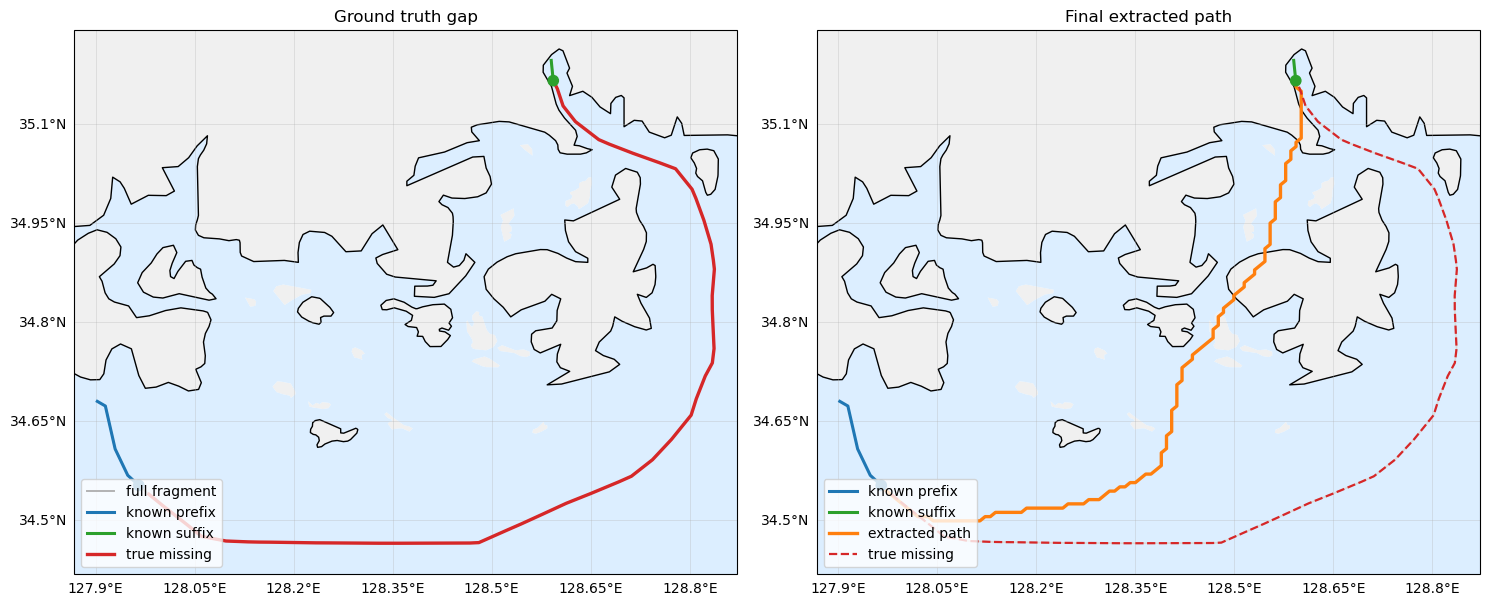

In [22]:
fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.0])

ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
set_map_style(ax1)
ax1.set_extent(window_extent, crs=ccrs.PlateCarree())
ax1.plot(fragment['lon'], fragment['lat'], color='0.7', linewidth=1.4, transform=ccrs.PlateCarree(), label='full fragment')
ax1.plot(fragment['lon'][:gap[0]], fragment['lat'][:gap[0]], color='tab:blue', linewidth=2.2, transform=ccrs.PlateCarree(), label='known prefix')
ax1.plot(fragment['lon'][gap[1]:], fragment['lat'][gap[1]:], color='tab:green', linewidth=2.2, transform=ccrs.PlateCarree(), label='known suffix')
ax1.plot(fragment['lon'][gap[0]:gap[1]], fragment['lat'][gap[0]:gap[1]], color='tab:red', linewidth=2.4, transform=ccrs.PlateCarree(), label='true missing')
ax1.scatter([fragment['lon'][gap[0] - 1], fragment['lon'][gap[1]]], [fragment['lat'][gap[0] - 1], fragment['lat'][gap[1]]], c=['tab:blue', 'tab:green'], s=55, transform=ccrs.PlateCarree(), zorder=5)
ax1.set_title('Ground truth gap')
ax1.legend(loc='lower left')

ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
set_map_style(ax2)
ax2.set_extent(window_extent, crs=ccrs.PlateCarree())
ax2.plot(fragment['lon'], fragment['lat'], color='0.85', linewidth=1.2, transform=ccrs.PlateCarree())
ax2.plot(fragment['lon'][:gap[0]], fragment['lat'][:gap[0]], color='tab:blue', linewidth=2.2, transform=ccrs.PlateCarree(), label='known prefix')
ax2.plot(fragment['lon'][gap[1]:], fragment['lat'][gap[1]:], color='tab:green', linewidth=2.2, transform=ccrs.PlateCarree(), label='known suffix')
if len(final_path_geo) > 0:
    ax2.plot(final_path_geo[:, 1], final_path_geo[:, 0], color='tab:orange', linewidth=2.4, transform=ccrs.PlateCarree(), label='extracted path')
ax2.plot(fragment['lon'][gap[0]:gap[1]], fragment['lat'][gap[0]:gap[1]], color='tab:red', linewidth=1.6, linestyle='--', transform=ccrs.PlateCarree(), label='true missing')
ax2.scatter([fragment['lon'][gap[0] - 1], fragment['lon'][gap[1]]], [fragment['lat'][gap[0] - 1], fragment['lat'][gap[1]]], c=['tab:blue', 'tab:green'], s=55, transform=ccrs.PlateCarree(), zorder=5)
ax2.set_title('Final extracted path')
ax2.legend(loc='lower left')

fig.tight_layout()
plt.show()

In [23]:
rows = [
    ('track_id', meta['track_id']),
    ('fragment_points', len(fragment)),
    ('gap_points', gap_len),
    ('known_pixels', int((known > 0).sum())),
    ('target_pixels', int((y > 0).sum())),
    ('pred_pixels_thr', int(pred_mask.sum())),
    ('corridor_pixels', int(hyst['corridor'].sum())),
    ('skeleton_pixels', int(skeleton.sum())),
    ('graph_nodes', skeleton_graph.number_of_nodes()),
    ('graph_edges', skeleton_graph.number_of_edges()),
    ('graph_path_pixels', len(graph_path)),
    ('final_path_pixels', len(final_path)),
    ('path_source', path_source),
    ('mean_prob_on_path', float(np.mean([probs[yx] for yx in final_path])) if final_path else float('nan')),
]

diag = pd.DataFrame(rows, columns=['metric', 'value'])
display(diag)

demo_ds.close()
h5.close()

,metric,value
0,track_id,30471
1,fragment_points,65
2,gap_points,55
3,known_pixels,110
4,target_pixels,825
5,pred_pixels_thr,3007
6,corridor_pixels,4862
7,skeleton_pixels,211
8,graph_nodes,211
9,graph_edges,268


In [34]:
MASS_OUT_DIR = RESEARCH_ROOT / 'output' / '27-track-restore-30'
MASS_OUT_DIR.mkdir(parents=True, exist_ok=True)

MASS_N = 30
MASS_SEED = 2026

rng_mass = np.random.default_rng(MASS_SEED)

frags_train_mass = load_frags(ARTIFACT_DIR / 'frags_train.parquet').copy()
frags_val_mass = load_frags(ARTIFACT_DIR / 'frags_val.parquet').copy()

frags_train_mass['split'] = 'train'
frags_val_mass['split'] = 'val'

frags_all_mass = pd.concat([frags_train_mass, frags_val_mass], ignore_index=True)
frags_all_mass = frags_all_mass.sample(frac=1.0, random_state=MASS_SEED).reset_index(drop=True)

mass_rows = frags_all_mass.head(MASS_N).copy()

mass_ds_train = TrackInpaintDataset(
    dataset_path=DATASET_PATH,
    frags_path=ARTIFACT_DIR / 'frags_train.parquet',
    track_index_path=ARTIFACT_DIR / 'track_index.pkl',
    density_path=ARTIFACT_DIR / 'density.npz',
    grid_cfg=grid_cfg,
    seed=123,
    return_meta=True,
)

mass_ds_val = TrackInpaintDataset(
    dataset_path=DATASET_PATH,
    frags_path=ARTIFACT_DIR / 'frags_val.parquet',
    track_index_path=ARTIFACT_DIR / 'track_index.pkl',
    density_path=ARTIFACT_DIR / 'density.npz',
    grid_cfg=grid_cfg,
    seed=123,
    return_meta=True,
)

mass_h5 = h5py.File(DATASET_PATH, 'r')
mass_track_index = load_track_index(ARTIFACT_DIR / 'track_index.pkl')

mass_model = ResUNetAttention(in_ch=4, out_ch=1, base_ch=32, groups=8, attn_heads=4).to(device)
load_checkpoint(CHECKPOINT_PATH, model=mass_model, map_location=device)
mass_model.eval()

display(mass_rows[['split', 'track_id', 's', 'e', 'points']].head())
print('examples to run:', len(mass_rows))
print('output dir     :', MASS_OUT_DIR)

,split,track_id,s,e,points
0,train,64321,0,39,39
1,train,58623,0,60,60
2,train,99800,17,49,32
3,train,84236,0,40,40
4,train,85970,0,32,32


examples to run: 30
output dir     : /Volumes/SSD/mark/Documents/Projects/marinetraffic-collector/research/output/27-track-restore-30


In [38]:
mass_results = []

for out_idx, row in tqdm(
    list(mass_rows.iterrows()),
    total=len(mass_rows),
    desc='Mass testing 30 examples',
):
    split = row['split']
    ds_local = mass_ds_train if split == 'train' else mass_ds_val

    frag_path = ARTIFACT_DIR / ('frags_train.parquet' if split == 'train' else 'frags_val.parquet')
    frag_df = load_frags(frag_path)

    match = frag_df[
        (frag_df['track_id'] == row['track_id'])
        & (frag_df['s'] == row['s'])
        & (frag_df['e'] == row['e'])
    ]
    if len(match) == 0:
        continue

    local_idx = int(match.index[0])
    example_mass = ds_local[local_idx]
    meta_mass = example_mass['meta']

    fragment_mass = read_track_fragment(
        mass_h5,
        mass_track_index,
        meta_mass['track_id'],
        meta_mass['s'],
        meta_mass['e'],
    )

    if not meta_mass['gaps']:
        continue

    gap_mass = tuple(meta_mass['gaps'][0])
    extent_mass = tuple(meta_mass['extent'])

    x_mass = example_mass['x'].numpy()
    y_mass = example_mass['y'].numpy()[0]
    known_mass = x_mass[0]

    with torch.no_grad():
        probs_mass = torch.sigmoid(
            mass_model(example_mass['x'].unsqueeze(0).to(device))
        )[0, 0].detach().cpu().numpy()

    start_cell_mass = point_to_grid_cell(
        fragment_mass['lat'][gap_mass[0] - 1],
        fragment_mass['lon'][gap_mass[0] - 1],
        extent_mass,
        grid_cfg,
    )
    end_cell_mass = point_to_grid_cell(
        fragment_mass['lat'][gap_mass[1]],
        fragment_mass['lon'][gap_mass[1]],
        extent_mass,
        grid_cfg,
    )

    start_mask_mass = make_anchor_mask(probs_mass.shape, start_cell_mass, radius=2)
    end_mask_mass = make_anchor_mask(probs_mass.shape, end_cell_mass, radius=2)

    hyst_mass = build_hysteresis_corridor(
        probs_mass,
        start_mask_mass,
        end_mask_mass,
        low_thr=0.20,
        high_thr=0.55,
    )

    skeleton_mass = zhang_suen_thinning(hyst_mass['corridor'], verbose=False)
    graph_mass = build_skeleton_graph(skeleton_mass, probs_mass)
    start_node_mass = closest_graph_node(graph_mass, start_cell_mass)
    end_node_mass = closest_graph_node(graph_mass, end_cell_mass)

    graph_path_mass = []
    if (
        start_node_mass is not None
        and end_node_mass is not None
        and nx.has_path(graph_mass, start_node_mass, end_node_mass)
    ):
        graph_path_mass = nx.shortest_path(
            graph_mass,
            source=start_node_mass,
            target=end_node_mass,
            weight='weight',
        )

    final_path_mass = graph_path_mass
    path_source_mass = 'skeleton graph'
    if not final_path_mass:
        final_path_mass = astar_grid_path(
            probs_mass,
            hyst_mass['corridor'],
            start_cell_mass,
            end_cell_mass,
            off_corridor_penalty=1.5,
        )
        path_source_mass = 'A* fallback'

    final_path_geo_mass = cells_to_lonlat(final_path_mass, extent_mass, grid_cfg)
    true_missing_geo_mass = np.column_stack([
        fragment_mass['lat'][gap_mass[0]:gap_mass[1]],
        fragment_mass['lon'][gap_mass[0]:gap_mass[1]],
    ]).astype(np.float64)

    pred_prob_for_map = np.ma.masked_where(probs_mass <= 1e-6, probs_mass)

    fig = plt.figure(figsize=(14, 6.5), constrained_layout=True)
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.0])

    ax_map = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
    set_map_style(ax_map)
    ax_map.set_extent(extent_mass, crs=ccrs.PlateCarree())

    ax_map.plot(
        fragment_mass['lon'],
        fragment_mass['lat'],
        color='0.82',
        linewidth=1.2,
        transform=ccrs.PlateCarree(),
        zorder=1,
    )
    ax_map.plot(
        fragment_mass['lon'][:gap_mass[0]],
        fragment_mass['lat'][:gap_mass[0]],
        color='tab:blue',
        linewidth=2.3,
        transform=ccrs.PlateCarree(),
        label='known start',
        zorder=3,
    )
    ax_map.plot(
        fragment_mass['lon'][gap_mass[1]:],
        fragment_mass['lat'][gap_mass[1]:],
        color='tab:green',
        linewidth=2.3,
        transform=ccrs.PlateCarree(),
        label='known end',
        zorder=3,
    )
    ax_map.plot(
        true_missing_geo_mass[:, 1],
        true_missing_geo_mass[:, 0],
        color='tab:red',
        linewidth=2.0,
        linestyle='--',
        transform=ccrs.PlateCarree(),
        label='true missing',
        zorder=4,
    )
    if len(final_path_geo_mass) > 0:
        ax_map.plot(
            final_path_geo_mass[:, 1],
            final_path_geo_mass[:, 0],
            color='tab:orange',
            linewidth=2.2,
            transform=ccrs.PlateCarree(),
            label='predicted path',
            zorder=5,
        )
    ax_map.scatter(
        [fragment_mass['lon'][gap_mass[0] - 1], fragment_mass['lon'][gap_mass[1]]],
        [fragment_mass['lat'][gap_mass[0] - 1], fragment_mass['lat'][gap_mass[1]]],
        c=['tab:blue', 'tab:green'],
        s=55,
        transform=ccrs.PlateCarree(),
        zorder=6,
    )
    ax_map.set_title(
        f"Map | #{len(mass_results)+1:02d} | track_id={meta_mass['track_id']}"
    )
    ax_map.legend(loc='lower left')

    ax_heat = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
    set_map_style(ax_heat)
    ax_heat.set_extent(extent_mass, crs=ccrs.PlateCarree())

    im = ax_heat.imshow(
        pred_prob_for_map,
        origin='lower',
        extent=extent_mass,
        transform=ccrs.PlateCarree(),
        vmin=0.0,
        vmax=1.0,
        cmap='magma',
        alpha=0.88,
        zorder=1,
    )
    ax_heat.plot(
        fragment_mass['lon'][:gap_mass[0]],
        fragment_mass['lat'][:gap_mass[0]],
        color='deepskyblue',
        linewidth=2.0,
        transform=ccrs.PlateCarree(),
        label='known start',
        zorder=3,
    )
    ax_heat.plot(
        fragment_mass['lon'][gap_mass[1]:],
        fragment_mass['lat'][gap_mass[1]:],
        color='lime',
        linewidth=2.0,
        transform=ccrs.PlateCarree(),
        label='known end',
        zorder=3,
    )
    ax_heat.plot(
        true_missing_geo_mass[:, 1],
        true_missing_geo_mass[:, 0],
        color='white',
        linewidth=1.8,
        linestyle='--',
        transform=ccrs.PlateCarree(),
        label='true missing',
        zorder=4,
    )
    if len(final_path_geo_mass) > 0:
        ax_heat.plot(
            final_path_geo_mass[:, 1],
            final_path_geo_mass[:, 0],
            color='cyan',
            linewidth=2.2,
            transform=ccrs.PlateCarree(),
            label='predicted path',
            zorder=5,
        )
    ax_heat.scatter(
        [fragment_mass['lon'][gap_mass[0] - 1], fragment_mass['lon'][gap_mass[1]]],
        [fragment_mass['lat'][gap_mass[0] - 1], fragment_mass['lat'][gap_mass[1]]],
        c=['deepskyblue', 'lime'],
        s=55,
        transform=ccrs.PlateCarree(),
        zorder=6,
    )
    ax_heat.set_title(
        f'NN probabilities heatmap | {path_source_mass} | meanP={float(np.mean([probs_mass[yx] for yx in final_path_mass])) if final_path_mass else float("nan"):.3f}'
    )
    ax_heat.legend(loc='lower left')
    cb = fig.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.03)
    cb.set_label('predicted probability')

    out_path = MASS_OUT_DIR / f'{len(mass_results)+1:02d}_{split}_track_{meta_mass["track_id"]}_s{meta_mass["s"]}_e{meta_mass["e"]}.png'
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)

    mass_results.append({
        'out_idx': len(mass_results) + 1,
        'split': split,
        'track_id': meta_mass['track_id'],
        's': meta_mass['s'],
        'e': meta_mass['e'],
        'gap': gap_mass,
        'path_source': path_source_mass,
        'path_len': len(final_path_mass),
        'graph_nodes': graph_mass.number_of_nodes(),
        'graph_edges': graph_mass.number_of_edges(),
        'mean_prob_on_path': float(np.mean([probs_mass[yx] for yx in final_path_mass])) if final_path_mass else float('nan'),
        'image_path': str(out_path),
    })

mass_results_df = pd.DataFrame(mass_results)
mass_results_df.to_csv(MASS_OUT_DIR / 'summary.csv', index=False)

display(mass_results_df.head())
print('saved images:', len(mass_results_df))
print('summary csv :', MASS_OUT_DIR / 'summary.csv')

Mass testing 30 examples: 100%|██████████| 30/30 [00:20<00:00,  1.47it/s]


,out_idx,split,track_id,s,e,gap,path_source,path_len,graph_nodes,graph_edges,mean_prob_on_path,image_path
0,1,train,64321,0,39,"(5, 34)",skeleton graph,113,134,148,0.867412,/Volumes/SSD/mark/Documents/Projects/marinetra...
1,2,train,58623,0,60,"(5, 55)",skeleton graph,115,196,230,0.844384,/Volumes/SSD/mark/Documents/Projects/marinetra...
2,3,train,99800,17,49,"(16, 21)",skeleton graph,20,137,166,0.998573,/Volumes/SSD/mark/Documents/Projects/marinetra...
3,4,train,84236,0,40,"(5, 35)",skeleton graph,95,159,218,0.857086,/Volumes/SSD/mark/Documents/Projects/marinetra...
4,5,train,85970,0,32,"(5, 27)",skeleton graph,93,131,146,0.913031,/Volumes/SSD/mark/Documents/Projects/marinetra...


saved images: 30
summary csv : /Volumes/SSD/mark/Documents/Projects/marinetraffic-collector/research/output/27-track-restore-30/summary.csv


In [36]:
display(mass_results_df[['out_idx', 'split', 'track_id', 'path_source', 'path_len', 'mean_prob_on_path']])

,out_idx,split,track_id,path_source,path_len,mean_prob_on_path
0,1,train,64321,skeleton graph,113,0.867412
1,2,train,58623,skeleton graph,115,0.844384
2,3,train,99800,skeleton graph,20,0.998573
3,4,train,84236,skeleton graph,95,0.857086
4,5,train,85970,skeleton graph,93,0.913031
5,6,train,30188,skeleton graph,130,0.791971
6,7,val,30471,skeleton graph,145,0.770985
7,8,train,60417,skeleton graph,64,0.886255
8,9,train,85182,skeleton graph,108,0.893401
9,10,train,60081,skeleton graph,71,0.920404


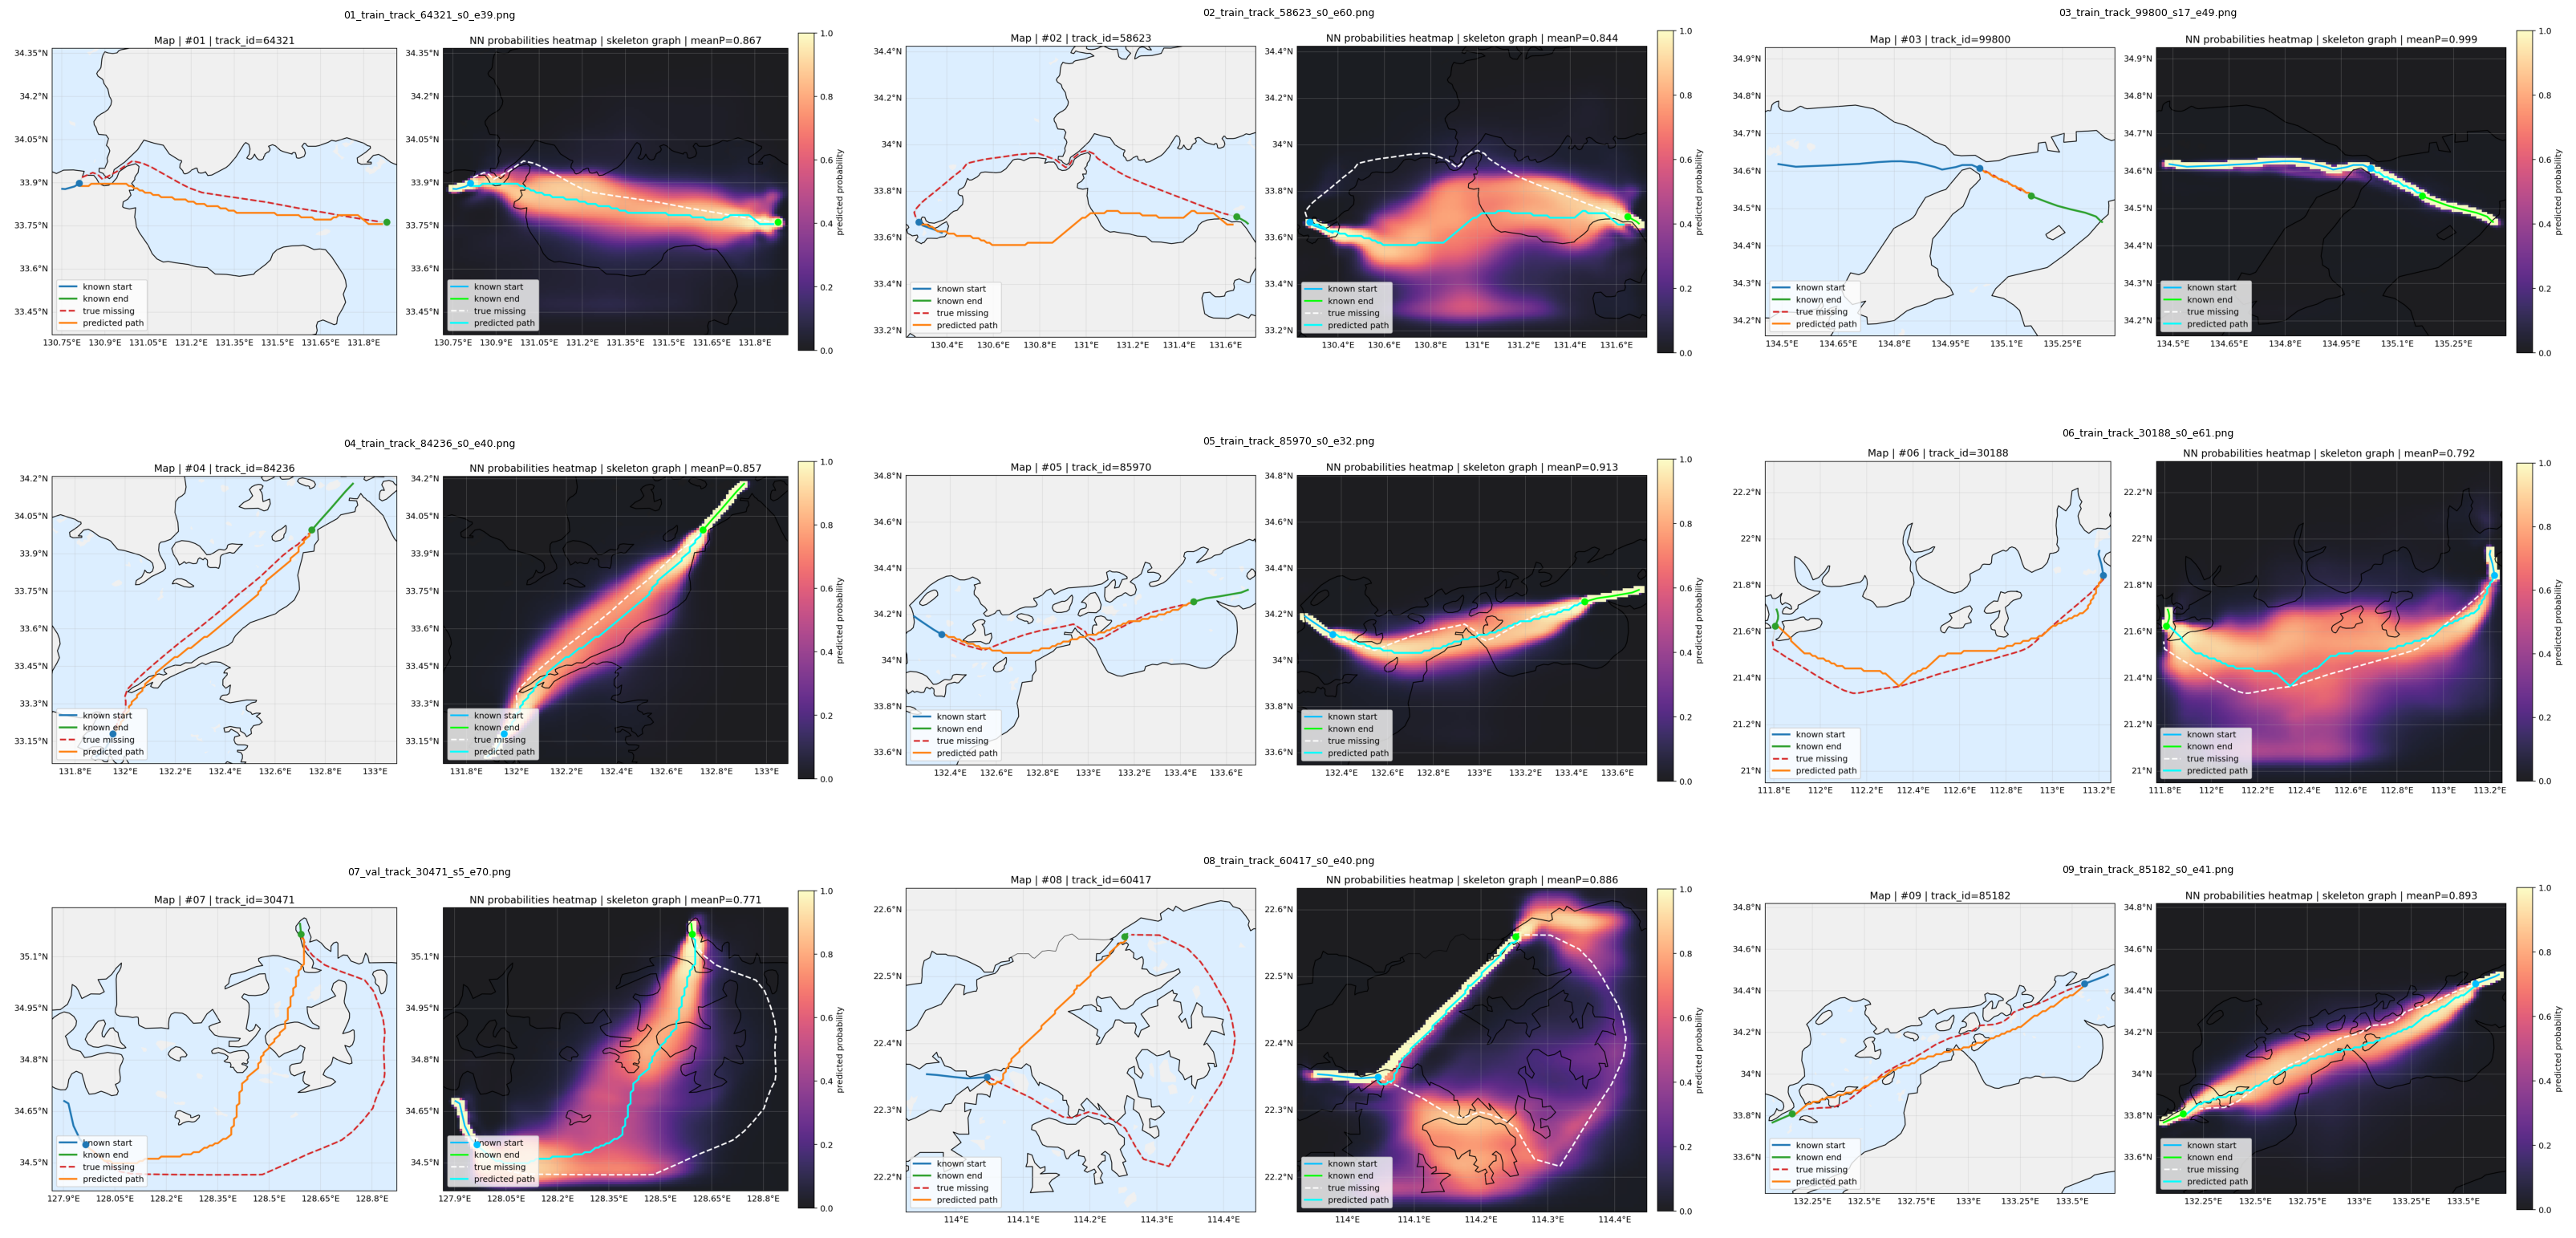

In [40]:
preview_paths = mass_results_df['image_path'].head(9).tolist()

fig, axs = plt.subplots(3, 3, figsize=(32, 16), constrained_layout=True)

for ax, img_path in zip(axs.flat, preview_paths, strict=False):
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(Path(img_path).name, fontsize=9)
    ax.axis('off')

for ax in axs.flat[len(preview_paths):]:
    ax.axis('off')

plt.show()